# 09. Lorenz-63 Ensemble Optimal Interpolation (EnOI)

이 노트북에서는 Lorenz-63 모델에 **EnOI(Ensemble Optimal Interpolation)** 를 적용한다.

세 가지 자료동화를 비교하면 다음과 같다.

| 방법 | background covariance | 비용 |
|------|----------------------|------|
| 3D-Var (02) | 사람이 정한 고정 행렬 B | 쌈 |
| EnKF (07) | 앙상블을 적분하며 매 순간 추정한 P^f (흐름 의존) | 비쌈 (앙상블 적분) |
| **EnOI (이번)** | **긴 free run에서 한 번 만든 climatological B (고정)** | 쌈 |

EnOI는 EnKF처럼 앙상블에서 공분산을 얻지만, 그 앙상블을 **적분하지 않고 고정**해 둔다.
즉 "EnKF의 공분산 추정 + 3D-Var의 저렴함"을 절충한 방법이다.

이번 실습의 목표는 다음과 같다.

1. 긴 free run에서 climatological anomaly를 뽑아 background covariance를 만든다.
2. 그 공분산의 구조를 관찰한다.
3. EnOI 자료동화를 수행한다.
4. free run / 3D-Var / EnKF / EnOI의 RMSE를 비교한다.
5. scaling 계수 alpha의 영향을 살펴본다.

## 1. 라이브러리 불러오기

In [1]:
import sys
from pathlib import Path

# --- bootstrap: 프로젝트 루트의 src/ 를 sys.path 에 추가해 lorenz_da import 를 보장한다 ---
#     editable 설치 위치에 의존하지 않으므로, 프로젝트를 다른 경로로 옮겨도 동작한다.
_p = Path.cwd().resolve()
for _d in (_p, *_p.parents):
    if (_d / "pyproject.toml").exists() or (_d / ".git").exists():
        if str(_d / "src") not in sys.path:
            sys.path.insert(0, str(_d / "src"))
        break

import numpy as np
import matplotlib.pyplot as plt

from lorenz_da.models.lorenz63 import lorenz63_rhs, lorenz63_default_initial_condition
from lorenz_da.numerics.euler import euler_step, integrate_euler
from lorenz_da.observations.operator import identity_observation_operator
from lorenz_da.observations.synthetic import (
    make_observation_indices,
    generate_synthetic_observations,
)
from lorenz_da.assimilation.three_dvar import analysis_3dvar
from lorenz_da.assimilation.enoi import (
    climatological_anomalies,
    enoi_covariance,
    enoi_analysis,
)
from lorenz_da.utils.diagnostics import rmse_time_series, mean_rmse

from lorenz_da.utils.io import find_project_root, get_output_dirs

## 2. 프로젝트 경로 설정

In [2]:
PROJECT_ROOT = find_project_root()
paths = get_output_dirs(PROJECT_ROOT)
FIGURE_DIR = paths["figures"]
TRAJECTORY_DIR = paths["trajectories"]
ASSIM_DIR = paths["assimilation"]
CKPT_DIR = paths["checkpoints"]

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/sanggyu/projects/lorenz-da-lab
Figure directory: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures


## 3. 실험 설정 및 truth/관측 불러오기

02번, 07번과 동일한 설정을 사용해 공정하게 비교한다.

In [3]:
dt = 0.005
tmax = 30.0
nsteps = int(tmax / dt)
obs_interval = 20
obs_std = 2.0
seed = 42

# truth
truth_path = TRAJECTORY_DIR / "lorenz63_truth_euler_dt0005_tmax30.npy"
time_path = TRAJECTORY_DIR / "lorenz63_time_dt0005_tmax30.npy"
if truth_path.exists() and time_path.exists():
    truth = np.load(truth_path); time = np.load(time_path)
else:
    x0_true0 = lorenz63_default_initial_condition()
    truth = integrate_euler(x0=x0_true0, dt=dt, nsteps=nsteps, rhs_func=lorenz63_rhs)
    time = np.arange(nsteps + 1) * dt
    np.save(truth_path, truth); np.save(time_path, time)

obs_indices = make_observation_indices(nsteps=nsteps, obs_interval=obs_interval)
obs_index_set = set(int(i) for i in obs_indices)
H_all = identity_observation_operator(3)
R_all = (obs_std**2) * np.eye(3)
x0_true = truth[0]
x0_background = x0_true + np.array([5.0, -5.0, 8.0])

# 관측 (02 재사용 / fallback)
obs_path = ASSIM_DIR / "02_observations_allvars.npy"
if obs_path.exists():
    observations_all = np.load(obs_path)
else:
    rng_obs = np.random.default_rng(seed)
    observations_all = generate_synthetic_observations(
        truth=truth, obs_indices=obs_indices, H=H_all, obs_std=obs_std, rng=rng_obs
    )
print("truth shape:", truth.shape, "| 관측 개수:", len(obs_indices))

truth shape: (6001, 3) | 관측 개수: 300


## 4. climatological 앙상블 만들기

EnOI의 핵심은 background covariance를 **긴 free run의 통계(climatology)** 에서 얻는 것이다.

기본 초기조건에서 모델을 길게 적분해 attractor를 충분히 돌게 한 뒤(spinup 제거),
그 상태들에서 무작위로 표본을 뽑아 평균을 뺀 anomaly를 만든다.

$$
\mathbf{a}_i = \mathbf{x}_{t_i} - \bar{\mathbf{x}}, \qquad
B = \frac{\alpha}{N-1}\sum_i \mathbf{a}_i \mathbf{a}_i^T
$$

In [4]:
# 긴 climatology run (truth와 다른 구간)
clim_run = integrate_euler(
    x0=np.array([2.0, 1.0, 1.0]), dt=0.01, nsteps=10000, rhs_func=lorenz63_rhs
)
clim_run = clim_run[2000:]  # spinup 제거

rng = np.random.default_rng(seed)
n_clim = 500
anomalies = climatological_anomalies(clim_run, n_members=n_clim, rng=rng)

B_raw = enoi_covariance(anomalies, alpha=1.0)
print("climatological covariance B (alpha=1):")
print(np.round(B_raw, 2))
print("\n대각 표준편차:", np.round(np.sqrt(np.diag(B_raw)), 2))

climatological covariance B (alpha=1):
[[63.96 63.66 -3.19]
 [63.66 81.14 -1.2 ]
 [-3.19 -1.2  59.37]]

대각 표준편차: [8.   9.01 7.71]


## 5. climatological covariance 구조 관찰

이 공분산은 Lorenz attractor의 평균적인 변동 구조를 담고 있다.
특히 x와 y는 강한 양의 상관을 가진다 (attractor가 대각 방향으로 길쭉하기 때문).

/var/folders/n3/7wsqvv4s6qb_qhnlq3fd1m9r0000gn/T/ipykernel_60075/3350899846.py:17: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n3/7wsqvv4s6qb_qhnlq3fd1m9r0000gn/T/ipykernel_60075/3350899846.py:17: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n3/7wsqvv4s6qb_qhnlq3fd1m9r0000gn/T/ipykernel_60075/3350899846.py:17: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n3/7wsqvv4s6qb_qhnlq3fd1m9r0000gn/T/ipykernel_60075/3350899846.py:17: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/n3/7wsqvv4s6qb_qhnlq3fd1m9r0000gn/T/ipykernel_60075/3350899846.py:19: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.savefig(fig_path, dpi=150)
/var/folders/n3/7wsqvv4s6qb_qhnlq3fd1m9

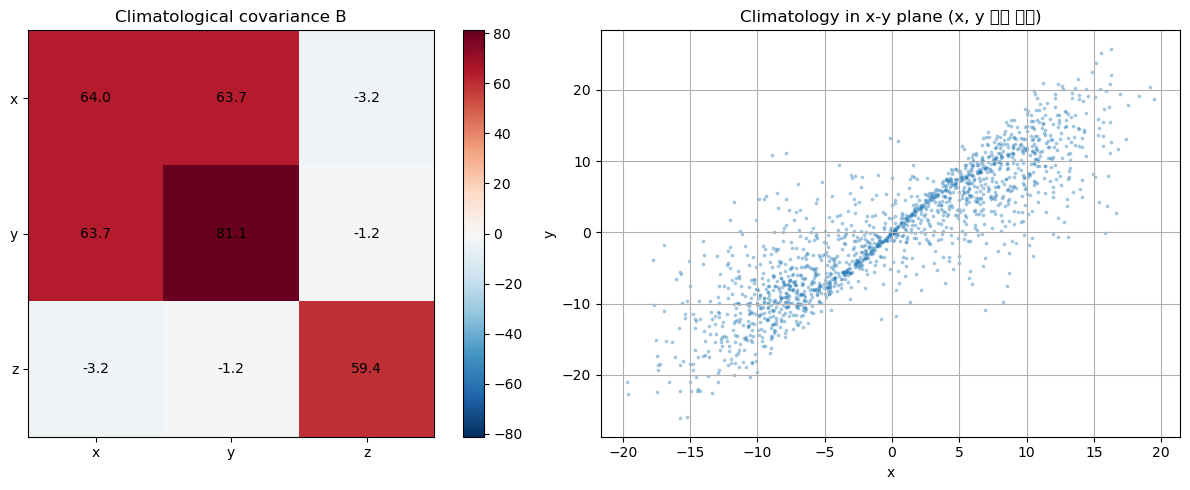

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/09_enoi_covariance_structure.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(B_raw, cmap="RdBu_r", vmin=-B_raw.max(), vmax=B_raw.max())
axes[0].set_xticks([0, 1, 2]); axes[0].set_xticklabels(["x", "y", "z"])
axes[0].set_yticks([0, 1, 2]); axes[0].set_yticklabels(["x", "y", "z"])
axes[0].set_title("Climatological covariance B")
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{B_raw[i, j]:.1f}", ha="center", va="center")
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].scatter(clim_run[::5, 0], clim_run[::5, 1], s=3, alpha=0.3)
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Climatology in x-y plane (x, y 강한 상관)")
axes[1].grid(True)

fig.tight_layout()
fig_path = FIGURE_DIR / "09_enoi_covariance_structure.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 6. EnOI 자료동화 사이클

EnOI는 단일 궤적을 적분하다가, 관측 시각마다 **고정된** $B$ 로 analysis를 수행한다.
앙상블을 적분하지 않으므로 EnKF보다 훨씬 싸다.

In [6]:
def run_enoi(x0, B_enoi):
    out = np.zeros_like(truth)
    out[0] = x0
    c = 0
    for n in range(nsteps):
        xb = euler_step(out[n], dt, lorenz63_rhs)
        if (n + 1) in obs_index_set:
            out[n + 1] = enoi_analysis(xb, observations_all[c], H_all, B_enoi, R_all)
            c += 1
        else:
            out[n + 1] = xb
    return out

## 7. scaling 계수 alpha의 영향

climatological 변동은 background error보다 훨씬 클 수 있으므로, $B$ 를 $\alpha$ 로 줄여 준다.
$\alpha$ 를 바꿔 가며 평균 RMSE가 가장 낮아지는 값을 찾는다.

alpha =  0.02 -> mean RMSE = 1.1367


alpha =  0.05 -> mean RMSE = 1.1061
alpha =  0.10 -> mean RMSE = 1.2114


alpha =  0.20 -> mean RMSE = 1.3423
alpha =  0.50 -> mean RMSE = 1.4860
alpha =  1.00 -> mean RMSE = 1.5703

최적 alpha: 0.05


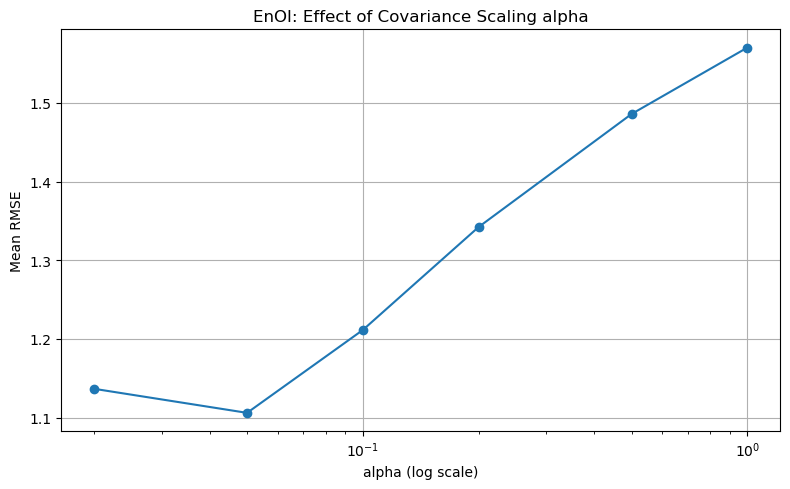

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/09_enoi_alpha_sensitivity.png


In [7]:
alphas = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
alpha_rmse = {}
for a in alphas:
    B_a = enoi_covariance(anomalies, alpha=a)
    da_a = run_enoi(x0_background, B_a)
    alpha_rmse[a] = mean_rmse(da_a, truth)
    print(f"alpha = {a:5.2f} -> mean RMSE = {alpha_rmse[a]:.4f}")

best_alpha = min(alpha_rmse, key=alpha_rmse.get)
print("\n최적 alpha:", best_alpha)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(list(alpha_rmse.keys()), list(alpha_rmse.values()), marker="o")
ax.set_xlabel("alpha (log scale)"); ax.set_ylabel("Mean RMSE")
ax.set_title("EnOI: Effect of Covariance Scaling alpha")
ax.grid(True)
fig.tight_layout()
fig_path = FIGURE_DIR / "09_enoi_alpha_sensitivity.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 8. free / 3D-Var / EnKF / EnOI 비교

최적 alpha로 만든 EnOI 결과를, 같은 truth·관측을 쓴 다른 방법들과 비교한다.
3D-Var(02)와 EnKF(07) 결과는 저장된 파일을 불러오고, 없으면 즉석에서 계산한다.

In [8]:
B_best = enoi_covariance(anomalies, alpha=best_alpha)
da_enoi = run_enoi(x0_background, B_best)

# free run (02)
p = ASSIM_DIR / "02_free_run_euler.npy"
if p.exists():
    free_run = np.load(p)
else:
    free_run = run_enoi(x0_background, B_best) * 0  # placeholder
    free_run[0] = x0_background
    for n in range(nsteps):
        free_run[n + 1] = euler_step(free_run[n], dt, lorenz63_rhs)

# 3D-Var (02)
p = ASSIM_DIR / "02_3dvar_allvars_euler.npy"
if p.exists():
    da_3dvar = np.load(p)
else:
    B_diag = (4.0**2) * np.eye(3)
    da_3dvar = run_enoi(x0_background, B_best) * 0
    da_3dvar[0] = x0_background; c = 0
    for n in range(nsteps):
        xb = euler_step(da_3dvar[n], dt, lorenz63_rhs)
        if (n + 1) in obs_index_set:
            da_3dvar[n + 1] = analysis_3dvar(xb, observations_all[c], H_all, B_diag, R_all); c += 1
        else:
            da_3dvar[n + 1] = xb

# EnKF (07)
p = ASSIM_DIR / "07_enkf_mean_allvars.npy"
enkf_mean = np.load(p) if p.exists() else None

print("Mean RMSE")
print(f"  Free run : {mean_rmse(free_run, truth):.4f}")
print(f"  3D-Var   : {mean_rmse(da_3dvar, truth):.4f}")
if enkf_mean is not None:
    print(f"  EnKF     : {mean_rmse(enkf_mean, truth):.4f}")
print(f"  EnOI     : {mean_rmse(da_enoi, truth):.4f}  (alpha={best_alpha})")

Mean RMSE
  Free run : 7.1667
  3D-Var   : 1.4099
  EnKF     : 0.6279
  EnOI     : 1.1061  (alpha=0.05)


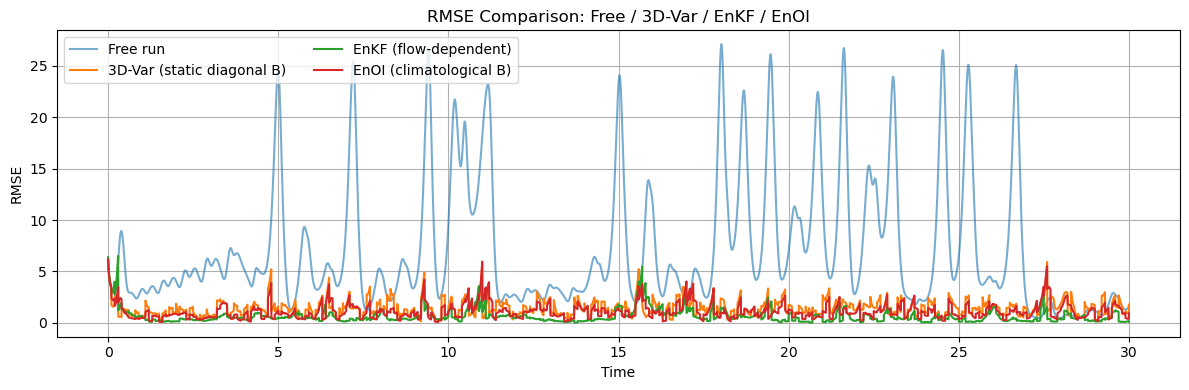

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/09_enoi_rmse_comparison.png


In [9]:
free_rmse = rmse_time_series(free_run, truth)
dvar_rmse = rmse_time_series(da_3dvar, truth)
enoi_rmse = rmse_time_series(da_enoi, truth)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, free_rmse, label="Free run", alpha=0.6)
ax.plot(time, dvar_rmse, label="3D-Var (static diagonal B)")
if enkf_mean is not None:
    ax.plot(time, rmse_time_series(enkf_mean, truth), label="EnKF (flow-dependent)")
ax.plot(time, enoi_rmse, label="EnOI (climatological B)")
ax.set_xlabel("Time"); ax.set_ylabel("RMSE")
ax.set_title("RMSE Comparison: Free / 3D-Var / EnKF / EnOI")
ax.legend(ncol=2); ax.grid(True)
fig.tight_layout()
fig_path = FIGURE_DIR / "09_enoi_rmse_comparison.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved figure:", fig_path)

## 9. 결과 저장

In [10]:
np.save(ASSIM_DIR / "09_enoi_analysis.npy", da_enoi)
np.save(ASSIM_DIR / "09_enoi_covariance.npy", B_best)

with open(ASSIM_DIR / "09_enoi_summary.txt", "w", encoding="utf-8") as f:
    f.write("Lorenz-63 EnOI 실습 요약\n\n")
    f.write(f"dt: {dt}, tmax: {tmax}, obs_interval: {obs_interval}, obs_std: {obs_std}\n")
    f.write(f"climatology 표본 수: {n_clim}, 최적 alpha: {best_alpha}\n\n")
    f.write("Mean RMSE\n")
    f.write(f"Free run : {mean_rmse(free_run, truth):.6f}\n")
    f.write(f"3D-Var   : {mean_rmse(da_3dvar, truth):.6f}\n")
    if enkf_mean is not None:
        f.write(f"EnKF     : {mean_rmse(enkf_mean, truth):.6f}\n")
    f.write(f"EnOI     : {mean_rmse(da_enoi, truth):.6f}\n")
print("Saved EnOI results to:", ASSIM_DIR)

Saved EnOI results to: /Users/sanggyu/projects/lorenz-da-lab/outputs/assimilation


## 10. 이번 실습 정리

이번 노트북에서는 Lorenz-63 모델에 EnOI를 적용했다.

확인한 내용은 다음과 같다.

1. EnOI는 긴 free run의 climatology에서 background covariance를 만든다.
2. 그 공분산은 attractor의 평균 변동 구조(예: x-y 강한 상관)를 담는다.
3. 앙상블을 적분하지 않으므로 EnKF보다 훨씬 싸지만, 공분산이 흐름을 반영하지 못한다(정적).
4. scaling 계수 alpha로 공분산 크기를 맞춰 주어야 한다.
5. 정확도는 보통 free run보다 좋고, 흐름 의존 공분산을 쓰는 EnKF보다는 못한 경향이 있다.

세 방법의 위치를 한 줄로 정리하면 다음과 같다.

**3D-Var(사람이 정한 고정 B) < EnOI(climatology 고정 B) < EnKF(흐름 의존 P^f)**
(공분산 품질 기준, 비용은 반대 방향)

이로써 Lorenz-63 자료동화 계열(변분: 02→03→04→05, 앙상블: 02→07→09)이 마무리된다.
다음(08)은 변수가 많은 Lorenz-96에서 EnKF를 적용하며 localization과 inflation을 다룬다.

In [11]:
print("아홉 번째 실습 완료")
print("다음 실습: 08_lorenz96_enkf.ipynb")

아홉 번째 실습 완료
다음 실습: 08_lorenz96_enkf.ipynb
